In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.metrics import confusion_matrix

In [3]:
dataset_path = "../dataset/customer_purchase_data.csv"
df = pd.read_csv(dataset_path)

In [4]:
df.head()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
0,40,1,66120.267939,8,0,30.568601,0,5,1
1,20,1,23579.773583,4,2,38.240097,0,5,0
2,27,1,127821.306432,11,2,31.633212,1,0,1
3,24,1,137798.623120,19,3,46.167059,0,4,1
4,31,1,99300.964220,19,1,19.823592,0,0,1


In [5]:
df['TimePerPurchase'] = df['TimeSpentOnWebsite'] / (df['NumberOfPurchases'] + 1)

In [6]:
X = df.drop(['PurchaseStatus'], axis=1)
y = df['PurchaseStatus']

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.7 , random_state = 35)

In [8]:
X_test

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,TimePerPurchase
1049,60,1,99682.145724,19,3,22.588059,0,5,1.129403
850,39,1,67538.497274,19,1,26.848587,0,3,1.342429
597,27,0,41017.286711,16,4,22.173253,0,1,1.304309
861,58,0,21580.380292,7,3,7.808775,0,1,0.976097
944,38,1,94558.763689,19,1,43.908840,0,0,2.195442
...,...,...,...,...,...,...,...,...,...
158,32,1,58387.764226,15,1,36.435791,1,5,2.277237
46,62,0,67931.932212,11,4,58.262726,0,5,4.855227
1258,50,0,51462.870398,11,0,40.019658,0,0,3.334972
305,50,0,90082.291856,11,1,46.922015,0,3,3.910168


In [9]:
scaler = StandardScaler()
num_cols = ['Age', 'AnnualIncome', 'NumberOfPurchases', 'TimeSpentOnWebsite', 'DiscountsAvailed']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [10]:
model = GradientBoostingClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9422222222222222

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       245
           1       0.95      0.93      0.94       205

    accuracy                           0.94       450
   macro avg       0.94      0.94      0.94       450
weighted avg       0.94      0.94      0.94       450


Confusion Matrix:
[[234  11]
 [ 15 190]]


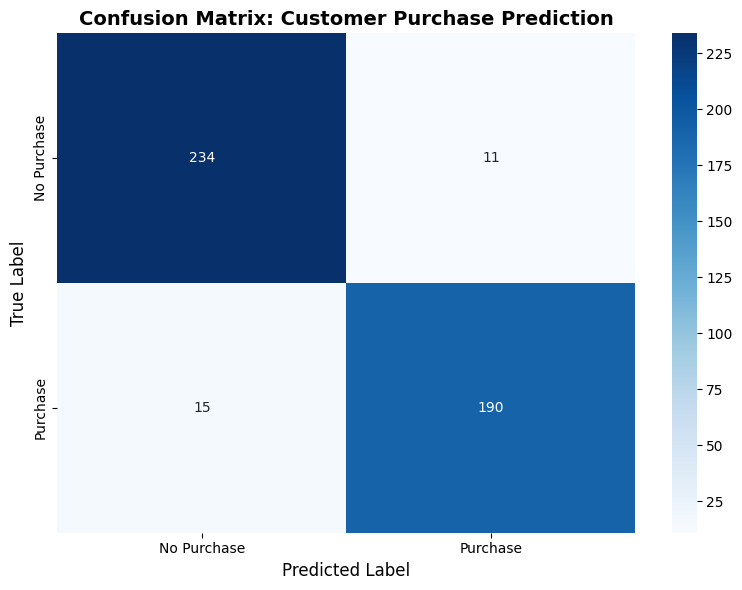

In [12]:

# Tính toán confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Cấu hình giao diện biểu đồ với tông màu Xanh dương
plt.figure(figsize=(8, 6))

# Vẽ heatmap với cmap='Blues'
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Purchase', 'Purchase'], 
            yticklabels=['No Purchase', 'Purchase'])

# Thêm nhãn và tiêu đề
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix: Customer Purchase Prediction', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()


In [13]:
# Liệt kê danh sách các biến đầu vào
features = X_train.columns.tolist()
print("Các biến cần truyền vào theo đúng thứ tự:")
print(features)

Các biến cần truyền vào theo đúng thứ tự:
['Age', 'Gender', 'AnnualIncome', 'NumberOfPurchases', 'ProductCategory', 'TimeSpentOnWebsite', 'LoyaltyProgram', 'DiscountsAvailed', 'TimePerPurchase']


In [16]:
import joblib

# 1. Lưu Model (Giả sử model của bạn tên là rf_xgboost hoặc rf)
joblib.dump(rf_xgboost, 'model_classification.pkl')

# 2. Lưu Scaler (Để dùng lại cho dữ liệu mới)
joblib.dump(scaler, 'scaler.pkl')

print("Đã lưu model và scaler thành công!")

Đã lưu model và scaler thành công!


In [14]:
from concrete.ml.sklearn import XGBClassifier as ConcreteXGBoostClassifier

In [26]:
init_params_xgb = {"max_depth": 3, "estimators": 100}
init_params_cml = {"n_bits": 7}
model = ConcreteXGBoostClassifier(**init_params_xgb, **init_params_cml)
model.fit(X_train, y_train)
circuit = model.compile(X_train)
print(circuit)

 %0 = _inputs                                           # EncryptedTensor<uint7, shape=(1, 9)>            ∈ [0, 127]
 %1 = transpose(%0)                                     # EncryptedTensor<uint7, shape=(9, 1)>            ∈ [0, 127]
 %2 = [[0 0 0 .. ... .. 0 0 0]]                         # ClearTensor<uint1, shape=(140, 9)>              ∈ [0, 1]
 %3 = matmul(%2, %1)                                    # EncryptedTensor<uint7, shape=(140, 1)>          ∈ [0, 127]
 %4 = 1                                                 # ClearScalar<uint1>                              ∈ [1, 1]
 %5 = multiply(%4, %3)                                  # EncryptedTensor<uint7, shape=(140, 1)>          ∈ [0, 127]
 %6 = 0                                                 # ClearScalar<uint1>                              ∈ [0, 0]
 %7 = add(%5, %6)                                       # EncryptedTensor<uint7, shape=(140, 1)>          ∈ [0, 127]
 %8 = [[ 64] [ 6 ...  4] [ 31]]                         # ClearTensor<

In [27]:
evaluation_result = {}
evaluation_result["max bit-width"] = circuit.graph.maximum_integer_bit_width()

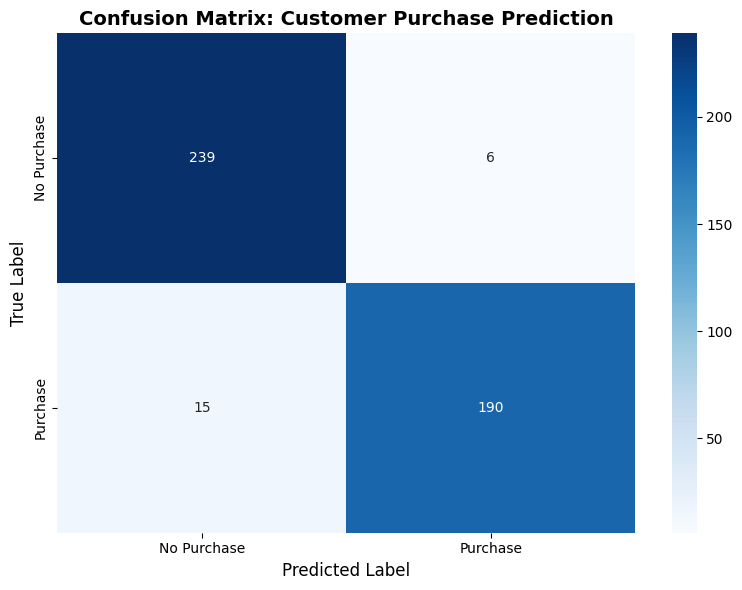

In [28]:
y_pred_simulate = model.predict(X_test, fhe="simulate")
evaluation_result["Accuracy (simulated)"] = accuracy_score(y_test, y_pred_simulate)

cm = confusion_matrix(y_test, y_pred_simulate)
# Cấu hình giao diện biểu đồ với tông màu Xanh dương
plt.figure(figsize=(8, 6))

# Vẽ heatmap với cmap='Blues'
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Purchase', 'Purchase'], 
            yticklabels=['No Purchase', 'Purchase'])

# Thêm nhãn và tiêu đề
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix: Customer Purchase Prediction', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

In [31]:
import time

# ── FHE thật: chỉ chạy trên N mẫu nhỏ để đo tốc độ ──
N = 5                          # chạy 5 mẫu, đủ để đo thời gian
X_fhe = X_test[:N]
y_fhe = y_test[:N]
evaluation_result["FHE samples"] = N

before_time = time.time()
y_pred_fhe = model.predict(X_fhe, fhe="execute")   # ← FHE thật
evaluation_result["FHE execution time (s/sample)"] = (
    time.time() - before_time
) / N

evaluation_result["Accuracy (FHE)"] = accuracy_score(y_fhe, y_pred_fhe)

In [32]:
evaluation_result

{'max bit-width': 9,
 'Accuracy (simulated)': 0.9533333333333334,
 'FHE samples': 5,
 'FHE execution time (s/sample)': 1.3776584148406983,
 'Accuracy (FHE)': 0.8}

In [37]:
from pathlib import Path
from concrete.ml.deployment import FHEModelDev
# ── Save FHE deployment files (circuit + keys metadata) ───────
DEPLOYMENT_PATH = Path("fhe-models")
DEPLOYMENT_PATH.mkdir(parents=True, exist_ok=True)

fhe_dev = FHEModelDev(path_dir=DEPLOYMENT_PATH, model=model)
fhe_dev.save(via_mlir=True)   # lưu: server.zip, client.zip, processing.json